## 12. Raw Source Frequency Validation Spot Check

The notebook primarily validates the curated quarterly modelling table. This light spot check reconciles two representative raw inputs against the curated quarterly values using the ETL rule in `src.transform.to_quarterly()` and the source-specific aggregation configured in `src.build_curated_dataset.SeriesSpec`. It is not a full raw-source audit.

cash_rate: monthly source, 372 raw rows, 1995-01-01 to 2025-12-01, 0 duplicate dates
wti_price: daily trading days source, 6367 raw rows, 2000-08-23 to 2025-12-31, 0 duplicate dates


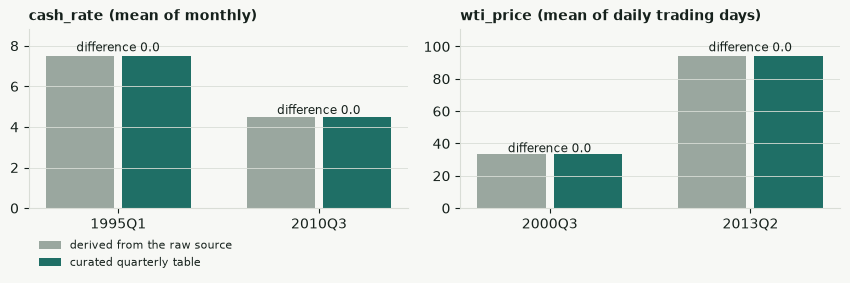

This spot check verifies representative monthly and daily inputs only. Full source-level validation remains an ETL/data-quality task; this EDA validates the curated quarterly table used for modelling.

In [15]:
from src.transform import to_quarterly
from src.validation import find_date_column

spot_specs = [
    {
        'variable': 'cash_rate',
        'source_family': 'RBA cash rate',
        'source_frequency': 'monthly',
        'path': ROOT / 'dataset' / 'rba' / 'cash_rate_1995_2025.csv',
        'value_col': 'cash_rate',
        'agg': 'mean',
    },
    {
        'variable': 'wti_price',
        'source_family': 'market WTI crude oil',
        'source_frequency': 'daily trading days',
        'path': ROOT / 'dataset' / 'market' / 'wti_crude_oil_1995_2025.csv',
        'value_col': 'Close',
        'agg': 'mean',
    },
]

spot_rows = []
frequency_rows = []
curated_lookup = df_model.set_index('quarter')
for spec in spot_specs:
    raw = pd.read_csv(spec['path'])
    date_col = find_date_column(raw)
    parsed_dates = pd.to_datetime(raw[date_col], errors='coerce')
    parsed_non_null = parsed_dates.dropna().sort_values()
    inferred_frequency = pd.infer_freq(parsed_non_null.head(12)) if len(parsed_non_null) >= 12 else None
    median_spacing_days = parsed_non_null.diff().dt.days.dropna().median() if len(parsed_non_null) > 1 else np.nan
    duplicate_dates = int(parsed_dates.duplicated().sum())

    frequency_rows.append({
        'variable': spec['variable'],
        'source_family': spec['source_family'],
        'source_frequency': spec['source_frequency'],
        'raw_rows': int(len(raw)),
        'date_col': date_col,
        'start_date': parsed_non_null.min().date() if len(parsed_non_null) else None,
        'end_date': parsed_non_null.max().date() if len(parsed_non_null) else None,
        'duplicate_dates': duplicate_dates,
        'inferred_frequency_head': inferred_frequency,
        'median_spacing_days': median_spacing_days,
    })

    quarterly = to_quarterly(raw, value_col=spec['value_col'], output_col=spec['variable'], agg=spec['agg'], date_col=date_col)
    common_quarters = [quarter for quarter in quarterly['quarter'] if quarter in curated_lookup.index and pd.notna(curated_lookup.loc[quarter, spec['variable']])]
    sample_quarters = []
    if common_quarters:
        sample_quarters.append(common_quarters[0])
    if len(common_quarters) > 1:
        sample_quarters.append(common_quarters[len(common_quarters) // 2])
    for quarter in dict.fromkeys(sample_quarters):
        raw_value = float(quarterly.loc[quarterly['quarter'] == quarter, spec['variable']].iloc[0])
        curated_value = float(curated_lookup.loc[quarter, spec['variable']])
        spot_rows.append({
            'variable': spec['variable'],
            'source_frequency': spec['source_frequency'],
            'aggregation_rule': spec['agg'],
            'spot_quarter': quarter,
            'raw_derived_value': raw_value,
            'curated_value': curated_value,
            'absolute_difference': abs(raw_value - curated_value),
            'match': bool(np.isclose(raw_value, curated_value, rtol=1e-8, atol=1e-8)),
        })

raw_frequency_spot_check = pd.DataFrame(frequency_rows)
raw_curated_reconciliation = pd.DataFrame(spot_rows)
for r in raw_frequency_spot_check.itertuples():
    print(f"{r.variable}: {r.source_frequency} source, {r.raw_rows} raw rows, {r.start_date} to {r.end_date}, "
          f"{r.duplicate_dates} duplicate dates")
with plt.rc_context(BOOK_STYLE):
    rc = raw_curated_reconciliation.copy()
    variables = list(dict.fromkeys(rc["variable"]))
    fig, axes = plt.subplots(1, len(variables), figsize=(8.6, 3.0))
    for ax, var in zip(np.atleast_1d(axes), variables):
        sub = rc[rc["variable"] == var].reset_index(drop=True)
        x = np.arange(len(sub))
        ax.bar(x - 0.19, sub["raw_derived_value"], width=0.34, color=MUTED, label="derived from the raw source")
        ax.bar(x + 0.19, sub["curated_value"], width=0.34, color=ACCENT, label="curated quarterly table")
        for xi, r in sub.iterrows():
            ax.text(xi, max(r["raw_derived_value"], r["curated_value"]) * 1.03, f"difference {r['absolute_difference']:.1f}",
                    ha="center", fontsize=8.3)
        ax.set_xticks(x, sub["spot_quarter"])
        ax.set_ylim(0, sub[["raw_derived_value", "curated_value"]].to_numpy().max() * 1.18)
        ax.set_title(f"{var} ({sub['aggregation_rule'].iloc[0]} of {sub['source_frequency'].iloc[0]})", loc="left",
                     fontsize=10, fontweight="bold")
        ax.grid(axis="x", visible=False)
    np.atleast_1d(axes)[0].legend(frameon=False, fontsize=8, loc="upper left", bbox_to_anchor=(0, -0.12), ncol=1)
    fig.tight_layout()
    plt.show()

display(Markdown('This spot check verifies representative monthly and daily inputs only. Full source-level validation remains an ETL/data-quality task; this EDA validates the curated quarterly table used for modelling.'))

**Interpretation.** Both spot-checked series reconcile exactly between the raw source and
the curated quarterly table — `cash_rate` at 1995Q1 and 2010Q3, `wti_price` at 2000Q3 and
2013Q2 all show `absolute_difference=0.0` and `match=True`. That's a narrow but real check:
it confirms `src.transform.to_quarterly()`'s aggregation rule (monthly mean for the cash
rate, daily-trading-day mean for WTI) is being applied as intended and isn't silently
introducing a rounding or alignment error during ETL, at least at these four checked points.